In [1]:
# Load required packages
using DelimitedFiles
using LinearAlgebra
using Plots
using Plots.PlotMeasures
# using Revise
gr()

# Add JPEC to path and load
push!(LOAD_PATH, joinpath(@__DIR__, "../.."))
using JPEC

# Initialize globals with proper grid parameters
# The kernel function expects coordinates on a regular theta grid
mth = 512  # Number of poloidal grid points
inputs = JPEC.Vacuum.VacuumInput(
    mtheta=mth,
    n=1,
)
settings = JPEC.Vacuum.WallGeometry()

JPEC.Vacuum.WallGeometry(true, true, Float64[], Float64[], Float64[], Float64[])

In [8]:
gren = readdlm("gren_output.txt")
grdgre = readdlm("grdgre_output.txt")

1024×1024 Matrix{Float64}:
 1.01029     0.0109242   0.00510057  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.010551    1.0096      0.0119597      0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.00441335  0.0120664   1.00799        0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.00861646  0.00514794  0.0116426      0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.00423214  0.00993819  0.00492354     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.00828728  0.00471427  0.00950913  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.00405386  0.00903313  0.00453778     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.00793556  0.0043552   0.0087304      0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.00388646  0.00843671  0.00422126     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.00762274  0.00410102  0.00819945     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 ⋮                                   ⋱                 ⋮              
 0.0         0.0         0.0         …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0         0.0         0.0            0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0         0

In [5]:
gren_fortran = readdlm("../../src/Vacuum/fortran/test_kernel_gren_output.txt")
grdgre_fortran = readdlm("../../src/Vacuum/fortran/test_kernel_grdgre_output.txt")

1034×1034 Matrix{Float64}:
 1.00662     0.0117079   0.00499824  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0116859   1.00665     0.0117821      0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.00497973  0.011745    1.00674        0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.00967102  0.00500698  0.0117511      0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.00462959  0.0096793   0.0049725      0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.00892579  0.00461944  0.00960202  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.00432077  0.00888443  0.00457442     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.00839469  0.00429445  0.00879186     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.00408795  0.00833462  0.00424801     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.00798184  0.00405721  0.0082471      0.0  0.0  0.0  0.0  0.0  0.0  0.0
 ⋮                                   ⋱                 ⋮              
 0.0         0.0         0.0         …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0         0.0         0.0            0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0         0

In [58]:
# Plot comparison of the two results, log scaled, equal aspect ratio
# set figsize = (600, 600) for square output

p = heatmap(range(1,mth), 
			range(1,mth), 
			log10.(abs.(gren - gren_fortran[1:mth, 1:mth]) .+ eps()), 
			title="Log-scaled difference in gren", 
			xlabel="Column Index", 
			ylabel="Row Index", 
			colorbar_title="Log10 Difference",
			antialiasing=false,
			clims = (-10, 0)
			)

porig = heatmap(range(1,mth), 
			range(1,mth), 
			log10.(abs.(gren_fortran[1:mth, 1:mth]) .+ eps()), 
			title="Log-scaled gren from Fortran", 
			xlabel="Column Index", 
			ylabel="Row Index", 
			colorbar_title="Log10 Value",
			antialiasing=false,
			clims = (-10, 0)
			)

plot!(p, aspect_ratio=1, size=(600,600), dpi=100, )
plot!(porig, aspect_ratio=1, size=(600,600), dpi=100, )
p = plot(p, porig, layout=(1,2), size=(1200,600))
yflip!()
savefig(p, "gren_comparison.pdf")


"/Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/notebooks/vacuum_tests/gren_comparison.pdf"

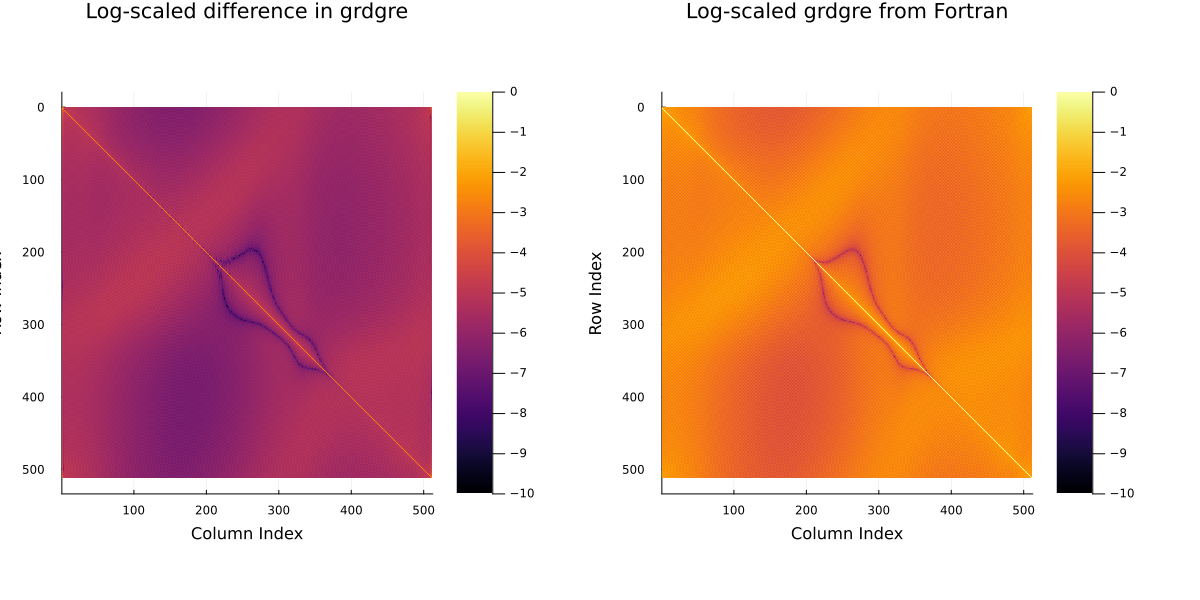

In [64]:
# The same thing for grdgre
p2 = heatmap(range(1,mth), 
			 range(1,mth), 
			 log10.(abs.(grdgre[1:mth, 1:mth] - grdgre_fortran[1:mth, 1:mth]) .+ eps()), 
			 title="Log-scaled difference in grdgre", 
			 xlabel="Column Index", 
			 ylabel="Row Index", 
			#  colorbar_title="Log10 Difference",
			 right_margin=10Plots.mm,
			 clims = (-10, 0)
			 )

porig2 = heatmap(range(1,mth), 
			 range(1,mth), 
			 log10.(abs.(grdgre_fortran[1:mth, 1:mth]) .+ eps()), 
			 title="Log-scaled grdgre from Fortran", 
			 xlabel="Column Index", 
			 ylabel="Row Index", 
			#  colorbar_title="Log10 Value",
			 right_margin=10Plots.mm,
			 clims = (-10, 0)
			 )

plot!(p2, aspect_ratio=1, size=(600,600), dpi=100, )
plot!(porig2, aspect_ratio=1, size=(600,600), dpi=100, )
p2 = plot(p2, porig2, layout=(1,2), size=(1200,600))
yflip!()
savefig(p2, "grdgre_comparison.pdf")
display(p2)